# Classifier Algorithms

This module provides an in-depth study of popular classification algorithms. You'll learn the mechanics, advantages, and use-cases of various classifiers.

## Learning Objectives

- Understand different classification algorithms
- Compare classifier performance
- Use advanced evaluation metrics
- Apply multiple classifiers to the same problem

**Key Concepts:**
- **Classification**: Predicting categories (spam/not spam, digit 0-9, species)
- **Multiple Algorithms**: Different algorithms work better for different problems
- **Comparison**: Test multiple algorithms to find the best one
- **Evaluation Metrics**: Accuracy, precision, recall, F1-score measure performance


In [ ]:
# ============================================
# IMPORTING LIBRARIES: Multiple Classifiers
# ============================================

# Scikit-learn: Machine learning library
from sklearn.datasets import load_digits  # Handwritten digits dataset
from sklearn.linear_model import LogisticRegression  # Logistic regression classifier
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors classifier
from sklearn.tree import DecisionTreeClassifier  # Decision tree classifier
from sklearn.ensemble import RandomForestClassifier  # Random Forest (ensemble) classifier
from sklearn.naive_bayes import GaussianNB  # Naive Bayes classifier

# Our custom utility functions
from src.models.supervised import split_data, evaluate_classifier  # Supervised learning utilities
import pandas as pd  # Data manipulation

# ============================================
# LOADING THE DATASET: Handwritten Digits
# ============================================

# load_digits() loads the Handwritten Digits dataset from scikit-learn
# This is a multiclass classification problem: predict digit (0-9) from image pixels
# No download needed - it's built into scikit-learn
digits = load_digits()  # Returns a Bunch object with data, target, etc.

# X = Features (inputs): Image pixels (8×8 = 64 pixels per image)
# digits.data contains pixel values (1797 samples × 64 features)
# We convert to DataFrame for easier manipulation
X = pd.DataFrame(digits.data)  # Features: 64 pixel values per image

# y = Target (output): Digit class (what we want to predict)
# digits.target contains class labels (0, 1, 2, ..., 9 for each sample)
# We convert to Series for easier manipulation
y = pd.Series(digits.target)  # Target: digit class (0-9)

print(f"Digits Dataset: {X.shape[0]} samples, {X.shape[1]} features")  # 1797 images, 64 pixels
print(f"Classes: {len(digits.target_names)}")  # 10 classes (digits 0-9)

# ============================================
# TRAIN/TEST SPLIT: Separating Data
# ============================================

# Split data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)

# ============================================
# TRAINING MULTIPLE CLASSIFIERS: Comparing Algorithms
# ============================================

# Create dictionary of different classifiers to compare
# Each algorithm has different strengths and weaknesses
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),  # Linear classifier
    'SVM': SVC(random_state=42),  # Support Vector Machine (can handle non-linear)
    'KNN': KNeighborsClassifier(n_neighbors=5),  # K-Nearest Neighbors (instance-based)
    'Decision Tree': DecisionTreeClassifier(random_state=42),  # Tree-based (interpretable)
    'Random Forest': RandomForestClassifier(random_state=42),  # Ensemble of trees (powerful)
    'Naive Bayes': GaussianNB()  # Probabilistic classifier (fast)
}

# Dictionary to store results for each classifier
results = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    # name = classifier name (e.g., 'Logistic Regression')
    # clf = classifier object (not yet trained)
    
    # Train the classifier on training data
    clf.fit(X_train, y_train)  # Learn from training examples
    
    # Evaluate on test data (unseen during training)
    eval_results = evaluate_classifier(clf, X_test, y_test)
    # Returns dictionary with accuracy and other metrics
    
    # Store accuracy for this classifier
    results[name] = eval_results['accuracy']
    
    # Display accuracy for this classifier
    print(f"{name}: {eval_results['accuracy']:.3f}")  # e.g., "Logistic Regression: 0.975"

# ============================================
# FINDING BEST CLASSIFIER: Comparing Performance
# ============================================

# max(results, key=results.get) finds the key (classifier name) with maximum value (accuracy)
# key=results.get means "use results[name] as the value to compare"
best = max(results, key=results.get)  # Name of best classifier

print(f"\nBest classifier: {best} with accuracy {results[best]:.3f}")  # Display winner
# Example: "Best classifier: SVM with accuracy 0.986"

# Interpretation:
# - Higher accuracy = better performance
# - Different algorithms work better for different problems
# - Always test multiple algorithms to find the best one


Digits Dataset: 1797 samples, 64 features
Classes: 10
Logistic Regression: 0.975
SVM: 0.986
KNN: 0.986
Decision Tree: 0.842
Random Forest: 0.972
Naive Bayes: 0.847

Best classifier: SVM with accuracy 0.986


## Advanced Evaluation Metrics

**Why Multiple Metrics?**
Accuracy alone doesn't tell the whole story. Different metrics reveal different aspects of performance:

- **Precision**: Of all predicted positives, how many were actually positive? (reduces false alarms)
- **Recall**: Of all actual positives, how many did we catch? (reduces missed detections)
- **F1 Score**: Balanced combination of precision and recall
- **ROC-AUC**: Ability to distinguish between classes (works with probabilities)

**When to Use Which Metric:**
- **Precision**: Important when false positives are costly (e.g., spam detection - don't want to block real emails)
- **Recall**: Important when false negatives are costly (e.g., cancer detection - don't want to miss cancers)
- **F1 Score**: When you need balance between precision and recall
- **ROC-AUC**: When you need to compare classifiers or choose optimal threshold


Precision: 0.946
Recall: 0.986
F1-Score: 0.966
ROC-AUC: 0.997


/home/goble54/spark-dev-workspace/VSP-AI-ML-Training/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


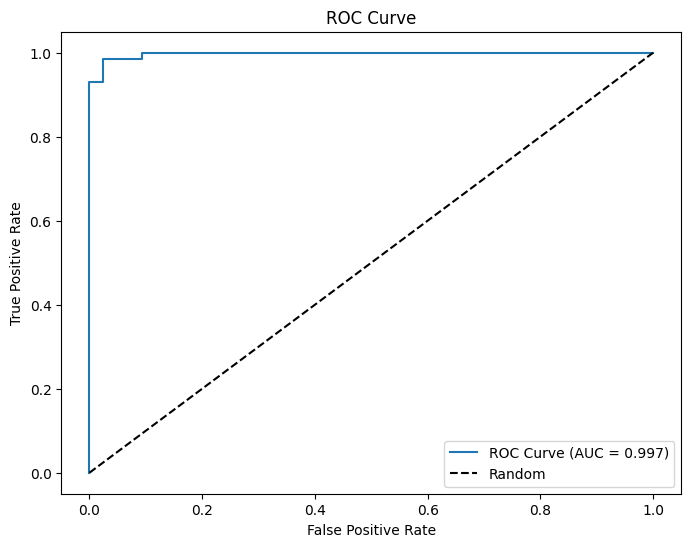

In [ ]:
# ============================================
# IMPORTING METRICS: Advanced Evaluation Tools
# ============================================

# Scikit-learn metrics for detailed classification evaluation
from sklearn.metrics import (
    precision_score,  # Calculate precision
    recall_score,  # Calculate recall (sensitivity)
    f1_score,  # Calculate F1 score (harmonic mean)
    roc_auc_score,  # Calculate ROC-AUC (area under ROC curve)
    roc_curve  # Generate ROC curve data
)
import matplotlib.pyplot as plt  # For plotting ROC curves

# ============================================
# BINARY CLASSIFICATION: For ROC Curve Example
# ============================================

# ROC curves are typically used for binary classification (2 classes)
# We'll use Breast Cancer dataset (binary: malignant vs benign)
from sklearn.datasets import load_breast_cancer  # Binary classification dataset

# Load Breast Cancer dataset
cancer = load_breast_cancer()  # Returns a Bunch object
X_bin = pd.DataFrame(cancer.data)  # Features: medical measurements
y_bin = pd.Series(cancer.target)  # Target: malignant (1) or benign (0)

# Split data into training and test sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = split_data(
    X_bin, y_bin, test_size=0.2, random_state=42
)

# ============================================
# TRAIN CLASSIFIER: Logistic Regression
# ============================================

# Create and train logistic regression for binary classification
lr = LogisticRegression(max_iter=1000, random_state=42)  # Create model
lr.fit(X_train_bin, y_train_bin)  # Train on training data

# ============================================
# MAKING PREDICTIONS: Using the Trained Classifier
# ============================================

# .predict() makes class predictions (0 or 1)
y_pred_bin = lr.predict(X_test_bin)  # Class predictions (0 or 1)
# Returns: array of class labels (0 = benign, 1 = malignant)

# .predict_proba() returns probability estimates for each class
y_pred_proba = lr.predict_proba(X_test_bin)[:, 1]  # Probabilities of class 1 (0 to 1)
# predict_proba() returns: [[P(class0), P(class1)], [P(class0), P(class1)], ...]
# [:, 1] extracts probability of class 1 (positive class, malignant)
# Range: 0 to 1 (higher = more confident it's malignant)

# ============================================
# CALCULATING ADVANCED METRICS
# ============================================

# Precision: Of predicted positives, how many were actually positive?
# precision = TP / (TP + FP)
# High precision = few false positives (when we predict malignant, we're usually right)
precision = precision_score(y_test_bin, y_pred_bin)
# Returns: precision score (0 to 1, higher is better)

# Recall (Sensitivity): Of actual positives, how many did we catch?
# recall = TP / (TP + FN)
# High recall = few false negatives (we catch most actual cancers)
recall = recall_score(y_test_bin, y_pred_bin)
# Returns: recall score (0 to 1, higher is better)

# F1 Score: Harmonic mean of precision and recall
# F1 = 2 × (precision × recall) / (precision + recall)
# Balances precision and recall (useful when you care about both)
f1 = f1_score(y_test_bin, y_pred_bin)
# Returns: F1 score (0 to 1, higher is better)

# ROC-AUC: Area under the ROC curve
# Measures ability to distinguish between classes
# Uses probability estimates (not just class predictions)
auc = roc_auc_score(y_test_bin, y_pred_proba)
# y_test_bin: True labels
# y_pred_proba: Probability estimates
# Returns: AUC score (0 to 1, 1.0 = perfect, 0.5 = random)

# ============================================
# DISPLAYING METRICS
# ============================================

print(f"Precision: {precision:.3f}")  # Precision score
print(f"Recall: {recall:.3f}")  # Recall score
print(f"F1-Score: {f1:.3f}")  # F1 score
print(f"ROC-AUC: {auc:.3f}")  # AUC score

# ============================================
# PLOTTING ROC CURVE: Visualizing Classification Performance
# ============================================

# ROC (Receiver Operating Characteristic) curve shows trade-off between
# True Positive Rate (TPR) and False Positive Rate (FPR) at different thresholds
# Useful for understanding model performance across different decision thresholds

# roc_curve() calculates TPR and FPR for different thresholds
fpr, tpr, _ = roc_curve(y_test_bin, y_pred_proba)
# y_test_bin: True labels
# y_pred_proba: Probability estimates
# Returns:
#   - fpr: False Positive Rate (x-axis)
#   - tpr: True Positive Rate (y-axis)
#   - _: Thresholds (we don't need these for plotting)

# Create figure
plt.figure(figsize=(8, 6))  # Figure size: 8×6 inches

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
# fpr: X-axis (False Positive Rate)
# tpr: Y-axis (True Positive Rate)
# label: Legend label with AUC score

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
# [0, 1]: X-coordinates (FPR from 0 to 1)
# [0, 1]: Y-coordinates (TPR from 0 to 1)
# 'k--': Black dashed line
# This represents a random classifier (AUC = 0.5)

# Label axes
plt.xlabel('False Positive Rate')  # X-axis: FPR (rate of false alarms)
plt.ylabel('True Positive Rate')  # Y-axis: TPR (rate of correct detections)
plt.title('ROC Curve')  # Chart title
plt.legend()  # Show legend

# Adjust layout
plt.tight_layout()
plt.show()  # Display the plot

# Interpretation:
# - ROC curve shows performance at different thresholds
# - Curve above diagonal = better than random
# - Closer to top-left corner = better performance
# - AUC = area under curve (higher = better)
# - AUC = 1.0: Perfect classifier
# - AUC = 0.5: Random classifier
# - AUC < 0.5: Worse than random (model is inverted!)


## Summary

In this module, you learned:
- Multiple classification algorithms (Logistic Regression, SVM, KNN, Decision Trees, Random Forest, Naive Bayes)
- How to compare classifier performance
- Advanced evaluation metrics (precision, recall, F1, ROC-AUC)
- When to use different classifiers

You now have a comprehensive understanding of classification algorithms!
